In [1]:
import pandas as pd

import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
PATH_DATA = os.getenv("PATH_DATA")

df = pd.read_csv(f"{PATH_DATA}/earthquake_data.csv")
df

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,"M 7.7 - 28 km SSW of Puerto El Triunfo, El Sal...",7.7,13-01-2001 17:33,0,8,NaN,0,912,us,427,0.000,0.0,mwc,60.000,13.0490,-88.660,"Puerto El Triunfo, El Salvador",NaN,NaN
778,"M 6.9 - 47 km S of Old Harbor, Alaska",6.9,10-01-2001 16:02,5,7,NaN,0,745,ak,0,0.000,0.0,mw,36.400,56.7744,-153.281,"Old Harbor, Alaska",North America,NaN
779,"M 7.1 - 16 km NE of Port-Olry, Vanuatu",7.1,09-01-2001 16:49,0,7,NaN,0,776,us,372,0.000,0.0,mwb,103.000,-14.9280,167.170,"Port-Olry, Vanuatu",NaN,Vanuatu
780,"M 6.8 - Mindanao, Philippines",6.8,01-01-2001 08:54,0,5,NaN,0,711,us,64,0.000,0.0,mwc,33.000,6.6310,126.899,"Mindanao, Philippines",NaN,NaN


In [3]:
# Liste des colonnes à supprimer (inutiles ou géographiques)
colonnes_a_supprimer = [
    'title', 'date_time', 'net', 'magType', 'latitude', 'longitude', 'location', 'continent', 'country'
]

# On retire les colonnes si elles existent
df_clean = df.drop(columns=[col for col in colonnes_a_supprimer if col in df.columns])
df_clean.head()

,magnitude,cdi,mmi,alert,tsunami,sig,nst,dmin,gap,depth
0,7.0,8,7,green,1,768,117,0.509,17.0,14.000
1,6.9,4,4,green,0,735,99,2.229,34.0,25.000
2,7.0,3,3,green,1,755,147,3.125,18.0,579.000
3,7.3,5,5,green,1,833,149,1.865,21.0,37.000
4,6.6,0,2,green,1,670,131,4.998,27.0,624.464


In [4]:
# Jeu de données pour la prédiction de 'alert'
df_alert = df_clean.dropna(subset=['alert'])

# Jeu de données pour la prédiction de 'sig'
df_sig = df_clean.drop(columns=['alert']) if 'alert' in df_clean.columns else df_clean.copy()

df_alert.head(), df_sig.head()

(   magnitude  cdi  mmi  alert  tsunami  sig  nst   dmin   gap    depth
 0        7.0    8    7  green        1  768  117  0.509  17.0   14.000
 1        6.9    4    4  green        0  735   99  2.229  34.0   25.000
 2        7.0    3    3  green        1  755  147  3.125  18.0  579.000
 3        7.3    5    5  green        1  833  149  1.865  21.0   37.000
 4        6.6    0    2  green        1  670  131  4.998  27.0  624.464,
    magnitude  cdi  mmi  tsunami  sig  nst   dmin   gap    depth
 0        7.0    8    7        1  768  117  0.509  17.0   14.000
 1        6.9    4    4        0  735   99  2.229  34.0   25.000
 2        7.0    3    3        1  755  147  3.125  18.0  579.000
 3        7.3    5    5        1  833  149  1.865  21.0   37.000
 4        6.6    0    2        1  670  131  4.998  27.0  624.464)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_alert = df_alert.drop(columns=['alert'])
colonnes_numeriques_alert = X_alert.select_dtypes(include=['float64', 'int64']).columns
scaler_alert = StandardScaler()
X_alert_scaled = X_alert.copy()
X_alert_scaled[colonnes_numeriques_alert] = scaler_alert.fit_transform(X_alert[colonnes_numeriques_alert])
y_alert = df_alert['alert']
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_alert_scaled, y_alert, test_size=0.2, random_state=42, stratify=y_alert)

X_sig = df_sig.drop(columns=['sig'])
colonnes_numeriques_sig = X_sig.select_dtypes(include=['float64', 'int64']).columns
scaler_sig = StandardScaler()
X_sig_scaled = X_sig.copy()
X_sig_scaled[colonnes_numeriques_sig] = scaler_sig.fit_transform(X_sig[colonnes_numeriques_sig])
y_sig = df_sig['sig']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sig_scaled, y_sig, test_size=0.2, random_state=42)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error

# Recherche simple d'hyperparamètres pour LogisticRegression
param_grid_lr = {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
lr = LogisticRegression(max_iter=200)
gs_lr = GridSearchCV(lr, param_grid_lr, cv=3)
gs_lr.fit(X_train_a, y_train_a)
y_pred_a = gs_lr.predict(X_test_a)
print('Classification report (alert):\n', classification_report(y_test_a, y_pred_a))

# Recherche simple d'hyperparamètres pour RandomForestRegressor
param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [3, 5, None]}
rf = RandomForestRegressor(random_state=42)
gs_rf = GridSearchCV(rf, param_grid_rf, cv=3)
gs_rf.fit(X_train_s, y_train_s)
y_pred_s = gs_rf.predict(X_test_s)
print('MSE (sig):', mean_squared_error(y_test_s, y_pred_s))

/home/camille/.pyenv/versions/EPSI_atelier-info-doc_projet/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
9 fits failed out of a total of 18.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "/home/camille/.pyenv/versions/EPSI_atelier-info-doc_projet/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/camille/.pyenv/versions/EPSI_atelier-info-doc_projet/lib/python3.12/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^

Classification report (alert):
               precision    recall  f1-score   support

       green       0.91      0.98      0.95        65
      orange       0.71      1.00      0.83         5
         red       1.00      1.00      1.00         2
      yellow       1.00      0.36      0.53        11

    accuracy                           0.90        83
   macro avg       0.91      0.84      0.83        83
weighted avg       0.92      0.90      0.89        83

MSE (sig): 64644.78381910826


In [17]:
import numpy as np

# y_pred_a = gs_lr.predict(X_test_a)
# rmse_clean_a = np.sqrt(mean_squared_error(y_test_a, y_pred_a))
# print(rmse_clean_a)

y_pred_s = gs_rf.predict(X_test_s)
rmse_clean_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
print(rmse_clean_s)

254.25338506912402


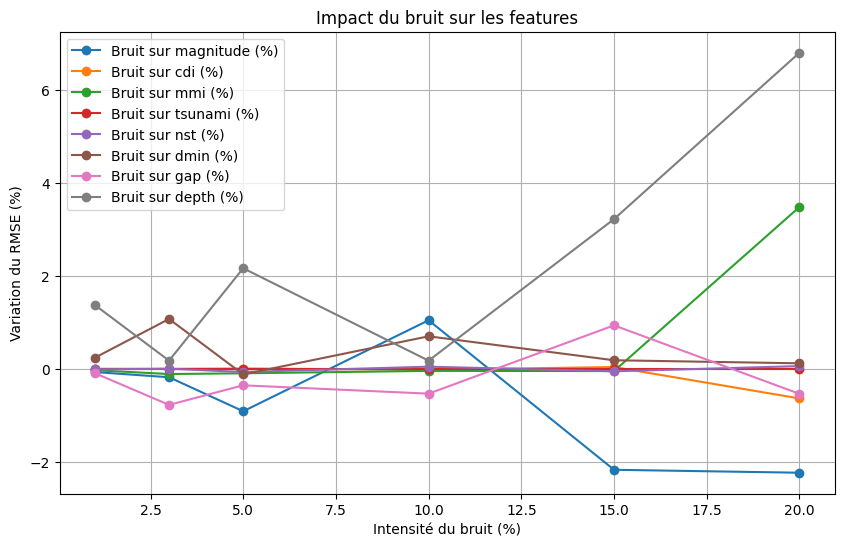

In [31]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings("ignore")

def evaluate_noise_impact(model, X_base, y_true, feature_idx, noise_level, scaler, rmse_clean):
    """
    Crée une copie de X, bruite une seule feature, et retourne la MSE.
    """
    X_noisy = X_base.copy()

    std_dev = X_base[:, feature_idx].std()

    noise = np.random.normal(loc=0, scale=std_dev * noise_level / 100, size=X_noisy.shape[0])
    X_noisy[:, feature_idx] += noise
    X_noisy = scaler.transform(X_noisy)

    preds_noisy = model.predict(X_noisy)
    rmse_noisy = np.sqrt(mean_squared_error(preds_noisy, y_true))
    variation = 100 * (rmse_noisy - rmse_clean) / rmse_clean

    diff_max = np.max(X_noisy[:, feature_idx]) - np.min(X_noisy[:, feature_idx])

    return variation


def plot_noise_impact(intensities, mse_values, feature_names):
    plt.figure(figsize=(10, 6))
    for idx, mse in enumerate(mse_values):
        plt.plot(intensities, mse, 'o-', label=f"Bruit sur {feature_names[idx]} (%)")
    plt.title("Impact du bruit sur les features")
    plt.xlabel("Intensité du bruit (%)")
    plt.ylabel("Variation du RMSE (%)")
    plt.legend()
    plt.grid()
    plt.show()

# Affichage de la courbe
intensities = np.array([1, 3, 5, 10, 15, 20])

X_train_s_, X_test_s_, y_train_s_, y_test_s_ = train_test_split(X_sig, y_sig, test_size=0.2, random_state=42)

mse_values_s = []
for idx in range(X_sig.shape[1]):
    mse_values_s.append([evaluate_noise_impact(gs_rf, X_test_s_.to_numpy(), y_test_s_, idx, n, scaler_sig, rmse_clean_s) for n in intensities])

plot_noise_impact(intensities, mse_values_s, X_sig.columns)